<a href="https://colab.research.google.com/github/rsouparnika/ML-2/blob/main/Learning_First_Order_Rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Learned rule: Female(x)  ->  Daughter(x, y)

Round 0: (most general)                      | pos_covered=2  neg_covered=2
Round 1: Female(x)                           | pos_covered=2  neg_covered=0


/tmp/ipykernel_459/3750349654.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


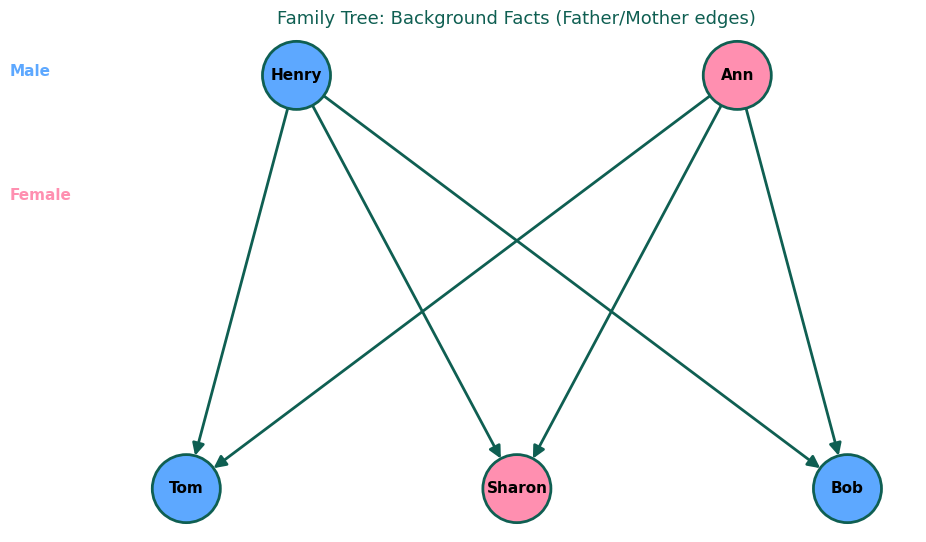

/tmp/ipykernel_459/3750349654.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


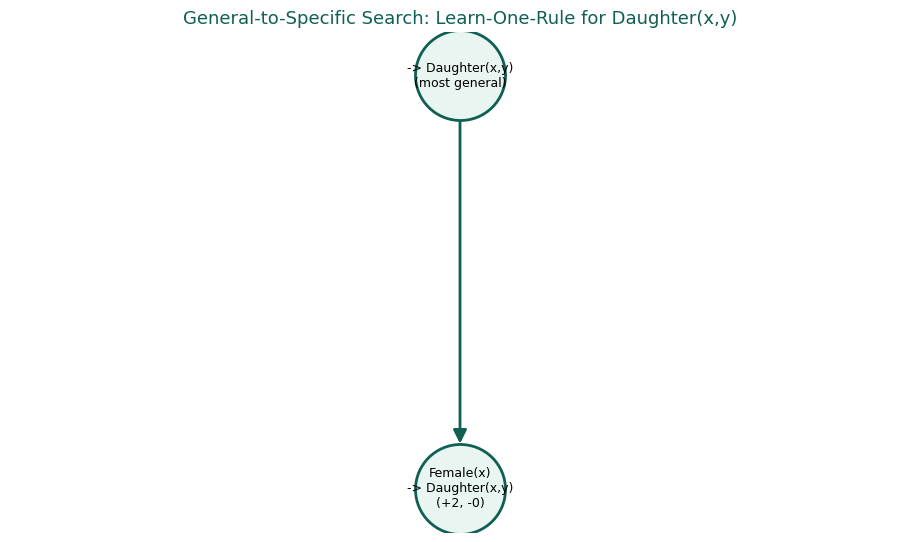

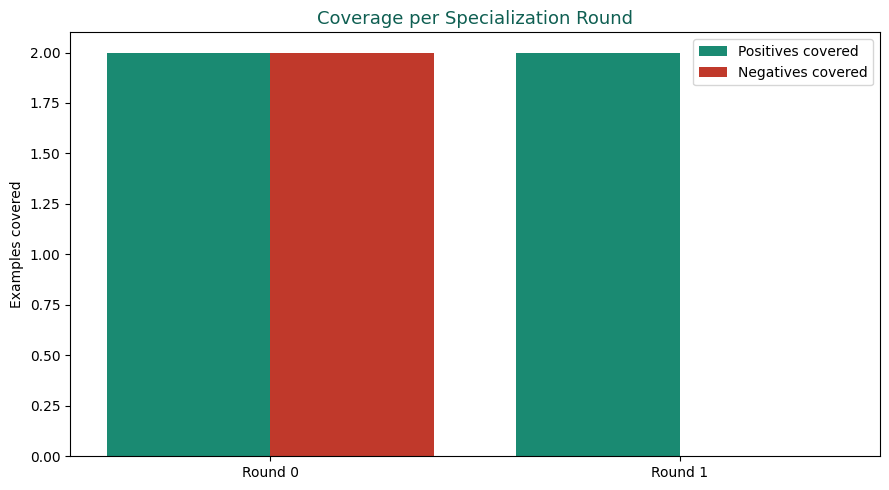

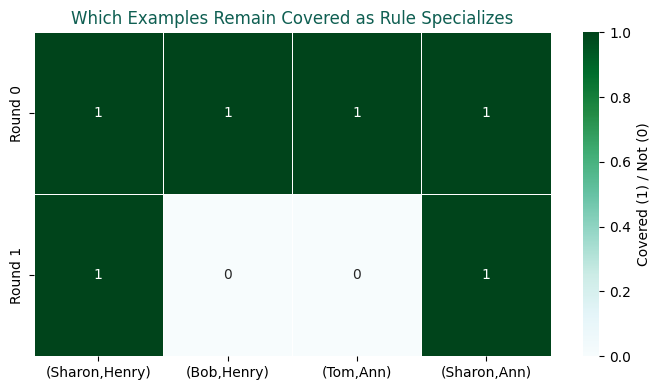


Final learned rule: Female(x)  ->  Daughter(x, y)

Verification against training data:


In [1]:
!pip install networkx matplotlib pandas seaborn -q

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ============================================================
# 1. DATA - Family relationships (matches slide 8)
# ============================================================
facts = {
    "Father": {("Henry", "Tom"), ("Henry", "Sharon"), ("Henry", "Bob")},
    "Mother": {("Ann", "Tom"), ("Ann", "Sharon"), ("Ann", "Bob")},
    "Male":   {("Henry",), ("Tom",), ("Bob",)},
    "Female": {("Ann",), ("Sharon",)},
}

examples = [
    ("Sharon", "Henry", True),
    ("Bob",    "Henry", False),
    ("Tom",    "Ann",   False),
    ("Sharon", "Ann",   True),
]

candidate_literals = {
    "Father(y,x)": lambda x, y: (y, x) in facts["Father"],
    "Mother(y,x)": lambda x, y: (y, x) in facts["Mother"],
    "Male(x)":     lambda x, y: (x,) in facts["Male"],
    "Female(x)":   lambda x, y: (x,) in facts["Female"],
}

# ============================================================
# 2. LEARN-ONE-FIRST-ORDER-RULE (general-to-specific search, slide 14)
# ============================================================
def evaluate_rule(literal_names, examples):
    pos, neg, covered = 0, 0, []
    for x, y, label in examples:
        satisfied = all(candidate_literals[lit](x, y) for lit in literal_names)
        if satisfied:
            covered.append((x, y, label))
            if label:
                pos += 1
            else:
                neg += 1
    return pos, neg, covered

def learn_one_rule(examples, candidate_literals):
    rule_body = []
    history = []
    round_num = 0
    while True:
        pos, neg, covered = evaluate_rule(rule_body, examples)
        history.append({
            "round": round_num,
            "rule": " AND ".join(rule_body) if rule_body else "(most general)",
            "pos_covered": pos,
            "neg_covered": neg,
        })
        if neg == 0:
            break

        scores = {}
        for lit in candidate_literals:
            if lit in rule_body:
                continue
            trial_body = rule_body + [lit]
            p, n, _ = evaluate_rule(trial_body, examples)
            scores[lit] = (p - n, p, n)

        best_lit = max(scores, key=lambda l: scores[l][0])
        rule_body.append(best_lit)
        round_num += 1

    final_pos, final_neg, final_covered = evaluate_rule(rule_body, examples)
    return rule_body, history, final_covered

rule_body, history, final_covered = learn_one_rule(examples, candidate_literals)
rule_str = " AND ".join(rule_body) + "  ->  Daughter(x, y)"
print("Learned rule:", rule_str)
print()
for h in history:
    print("Round {}: {:35s} | pos_covered={}  neg_covered={}".format(
        h["round"], h["rule"], h["pos_covered"], h["neg_covered"]))

# ============================================================
# 3. VISUALIZATION 1 - Family Tree (pictorial representation, slide 8)
# ============================================================
FT = nx.DiGraph()
FT.add_edges_from([
    ("Henry", "Tom"), ("Henry", "Sharon"), ("Henry", "Bob"),
    ("Ann", "Tom"), ("Ann", "Sharon"), ("Ann", "Bob"),
])

pos_ft = {
    "Henry": (-1, 1), "Ann": (1, 1),
    "Tom": (-1.5, 0), "Sharon": (0, 0), "Bob": (1.5, 0),
}

male_color, female_color = "#5da8ff", "#ff8fb0"
node_colors = []
for n in FT.nodes():
    if n in ("Henry", "Tom", "Bob"):
        node_colors.append(male_color)
    else:
        node_colors.append(female_color)

plt.figure(figsize=(8, 5))
nx.draw(
    FT, pos_ft, with_labels=True, node_size=2400,
    node_color=node_colors, edgecolors="#0f5f52", linewidths=2,
    font_size=11, font_weight="bold", arrows=True, arrowsize=18,
    edge_color="#0f5f52", width=2
)
plt.title("Family Tree: Background Facts (Father/Mother edges)", fontsize=13, color="#0f5f52")
plt.text(-2.3, 1, "Male", color=male_color, fontsize=11, fontweight="bold")
plt.text(-2.3, 0.7, "Female", color=female_color, fontsize=11, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

# ============================================================
# 4. VISUALIZATION 2 - Search Lattice (general -> specific), slide 13
# ============================================================
G = nx.DiGraph()
node_labels = {}
prev_node = "root"
G.add_node(prev_node)
node_labels[prev_node] = "-> Daughter(x,y)\n(most general)"

for i, h in enumerate(history[1:], start=1):
    node = "step{}".format(i)
    G.add_node(node)
    G.add_edge(prev_node, node)
    node_labels[node] = "{}\n-> Daughter(x,y)\n(+{}, -{})".format(
        h["rule"], h["pos_covered"], h["neg_covered"])
    prev_node = node

plt.figure(figsize=(9, 5))
pos = {n: (0, -i) for i, n in enumerate(G.nodes())}
nx.draw(
    G, pos, with_labels=False, node_size=4200,
    node_color="#e8f5f0", edgecolors="#0f5f52", linewidths=2,
    arrows=True, arrowsize=20, edge_color="#0f5f52", width=2
)
for n, (px, py) in pos.items():
    plt.text(px, py, node_labels[n], ha="center", va="center", fontsize=9, wrap=True)
plt.title("General-to-Specific Search: Learn-One-Rule for Daughter(x,y)", fontsize=13, color="#0f5f52")
plt.axis("off")
plt.tight_layout()
plt.show()

# ============================================================
# 5. VISUALIZATION 3 - Per-round coverage bars
# ============================================================
rounds = [h["round"] for h in history]
pos_vals = [h["pos_covered"] for h in history]
neg_vals = [h["neg_covered"] for h in history]

x_idx = range(len(rounds))
plt.figure(figsize=(9, 5))
plt.bar([i - 0.2 for i in x_idx], pos_vals, width=0.4, label="Positives covered", color="#1a8a72")
plt.bar([i + 0.2 for i in x_idx], neg_vals, width=0.4, label="Negatives covered", color="#c0392b")
plt.xticks(list(x_idx), ["Round {}".format(r) for r in rounds])
plt.ylabel("Examples covered")
plt.title("Coverage per Specialization Round", fontsize=13, color="#0f5f52")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6. VISUALIZATION 4 - Coverage evolution heatmap (examples x rounds)
# ============================================================
example_ids = ["({},{})".format(x, y) for x, y, _ in examples]
heat_data = []
for h_i in range(len(history)):
    body = rule_body[:h_i]
    row = []
    for x, y, label in examples:
        satisfied = all(candidate_literals[lit](x, y) for lit in body)
        row.append(1 if satisfied else 0)
    heat_data.append(row)

heat_df = pd.DataFrame(heat_data, index=["Round {}".format(h["round"]) for h in history], columns=example_ids)

plt.figure(figsize=(7, 4))
sns.heatmap(heat_df, annot=True, cmap="BuGn", cbar_kws={"label": "Covered (1) / Not (0)"},
            linewidths=0.5, linecolor="white")
plt.title("Which Examples Remain Covered as Rule Specializes", fontsize=12, color="#0f5f52")
plt.tight_layout()
plt.show()

# ============================================================
# 7. Final verification table (matches slide 18)
# ============================================================
print()
print("Final learned rule:", rule_str)
print()
print("Verification against training data:")
verify_rows = []
for x, y, label in examples:
    lit_results = {lit: candidate_literals[lit](x, y) for lit in rule_body}
    satisfied = all(lit_results.values())
    row = {"Instance": "({}, {})".format(x, y)}
    for lit, val in lit_results.items():
        row[lit] = "T" if val else "F"
    row["Rule Result"] = "Covered" if satisfied else "Not covered"
    row["Class"] = "+" if label else "-"
    verify_rows.append(row)
verify_df = pd.DataFrame(verify_rows)

LEARNED MOVIE RECOMMENDATION RULE

Learned rule: HighRated(y) AND User(x) AND Movie(y) AND LikesComedy(x)  ->  Recommend(x,y)

LEARNING HISTORY

Round 0: (most general)                                     | positive=6  negative=3
Round 1: HighRated(y)                                       | positive=6  negative=1
Round 2: HighRated(y) AND User(x)                           | positive=6  negative=1
Round 3: HighRated(y) AND User(x) AND Movie(y)              | positive=6  negative=1
Round 4: HighRated(y) AND User(x) AND Movie(y) AND LikesComedy(x) | positive=4  negative=0


/tmp/ipykernel_459/1914339570.py:517: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


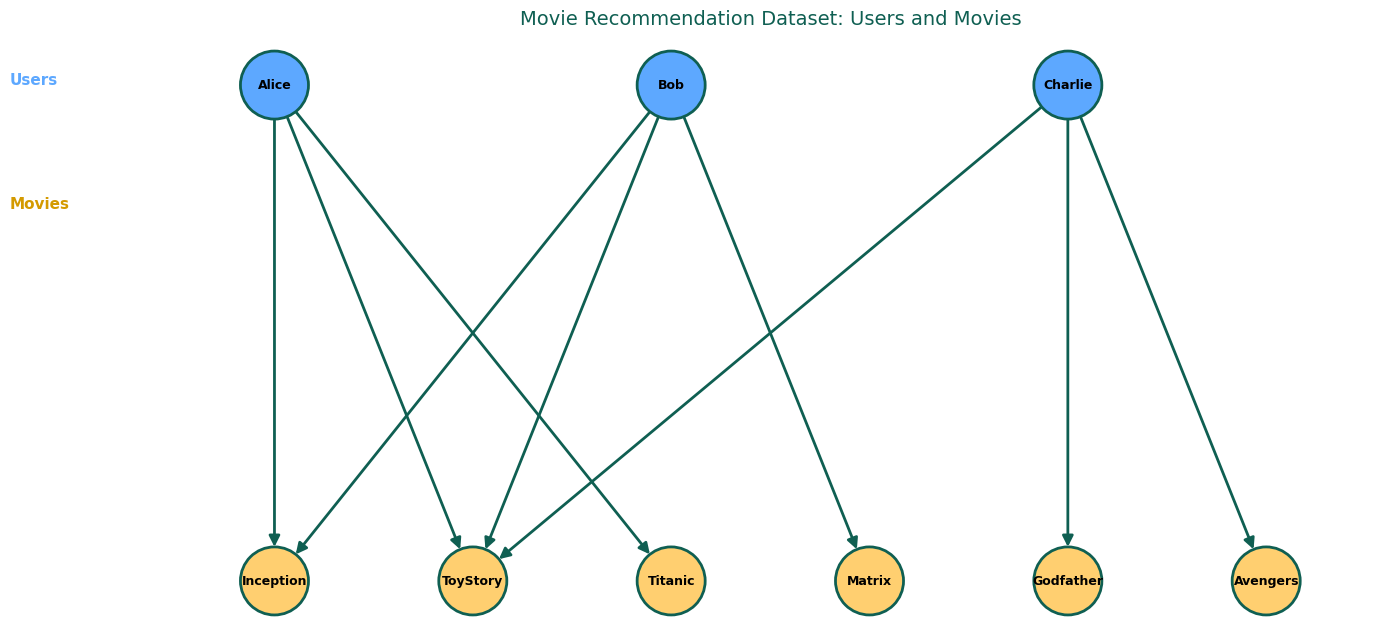

/tmp/ipykernel_459/1914339570.py:647: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


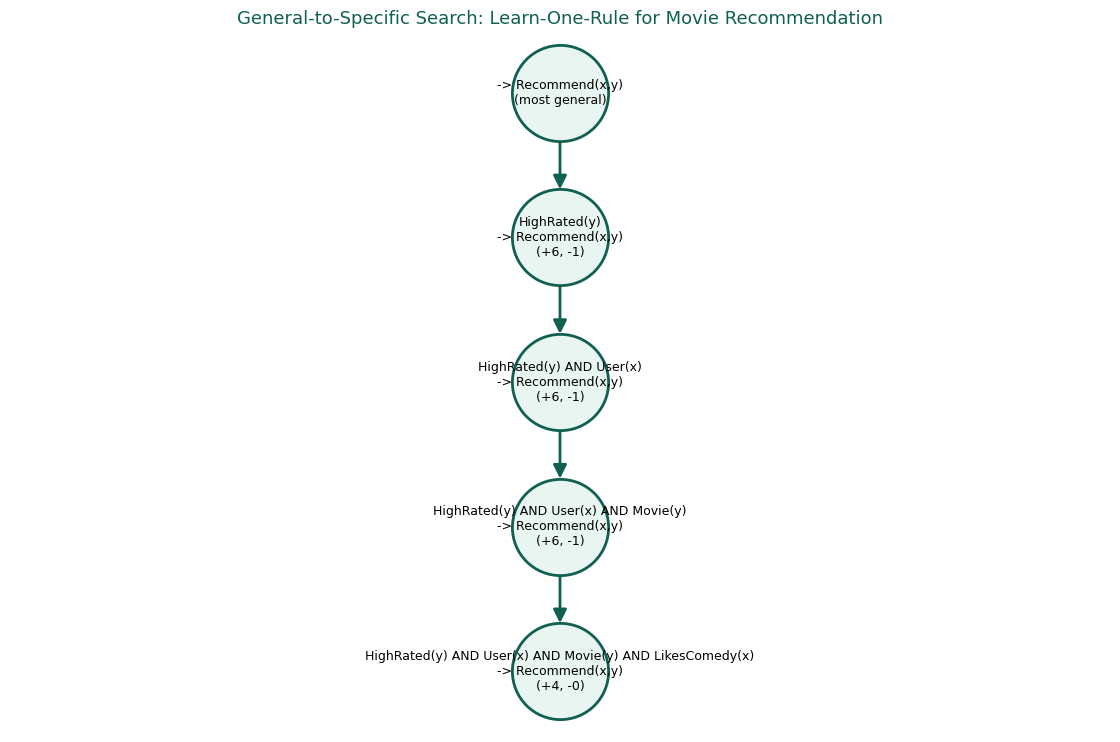

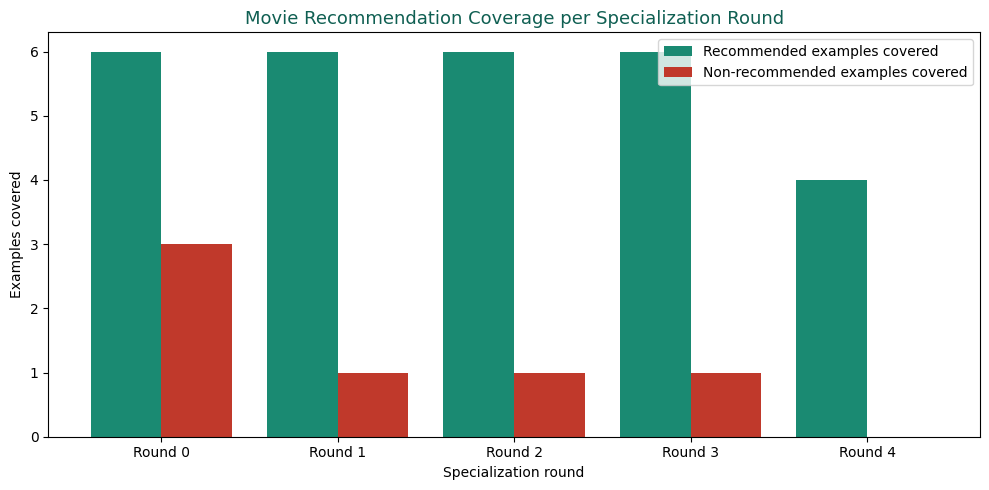

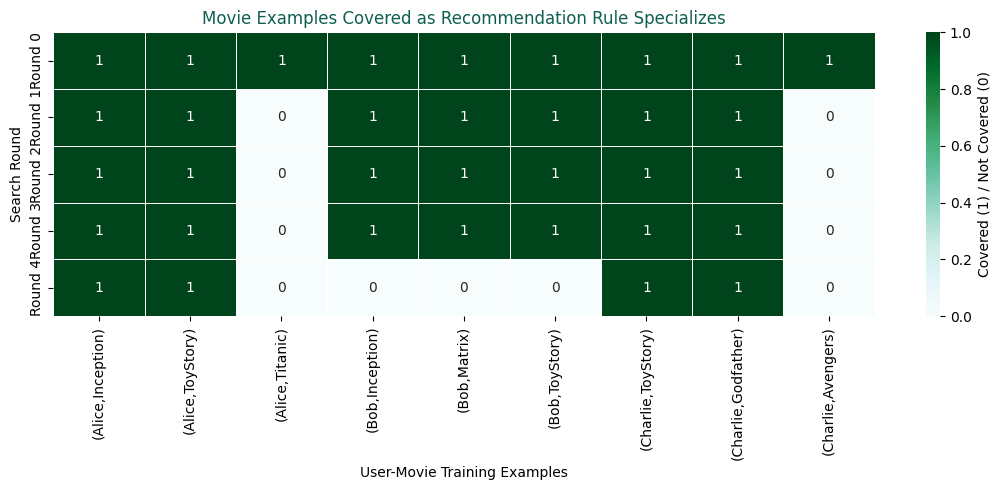


FINAL VERIFICATION

Final learned rule: HighRated(y) AND User(x) AND Movie(y) AND LikesComedy(x)  ->  Recommend(x,y)



,User-Movie,HighRated(y),User(x),Movie(y),LikesComedy(x),Rule Result,Actual Class
0,"(Alice, Inception)",T,T,T,T,Recommended,+
1,"(Alice, ToyStory)",T,T,T,T,Recommended,+
2,"(Alice, Titanic)",F,T,T,T,Not Recommended,-
3,"(Bob, Inception)",T,T,T,F,Not Recommended,+
4,"(Bob, Matrix)",T,T,T,F,Not Recommended,+
5,"(Bob, ToyStory)",T,T,T,F,Not Recommended,-
6,"(Charlie, ToyStory)",T,T,T,T,Recommended,+
7,"(Charlie, Godfather)",T,T,T,T,Recommended,+
8,"(Charlie, Avengers)",F,T,T,T,Not Recommended,-



MOVIE RECOMMENDATION DEMO

Alice -> ['Matrix', 'Inception', 'ToyStory', 'Godfather']

Bob -> []

Charlie -> ['Matrix', 'Inception', 'ToyStory', 'Godfather']


In [3]:
!pip install networkx matplotlib pandas seaborn -q

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# ============================================================
# 1. DATA - MOVIE RECOMMENDATION
# ============================================================
# Goal:
# Learn a rule for:
#
# Recommend(user, movie)
#
# using user preferences and movie properties.
# ============================================================


facts = {

    # --------------------------------------------------------
    # USER PREFERENCES
    # --------------------------------------------------------

    "LikesAction": {
        ("Alice",),
        ("Bob",)
    },

    "LikesComedy": {
        ("Alice",),
        ("Charlie",)
    },

    "LikesDrama": {
        ("Bob",),
        ("Charlie",)
    },

    "LikesSciFi": {
        ("Alice",),
        ("Bob",)
    },


    # --------------------------------------------------------
    # MOVIE GENRES
    # --------------------------------------------------------

    "Action": {
        ("Inception",),
        ("Avengers",)
    },

    "Comedy": {
        ("ToyStory",),
        ("Hangover",)
    },

    "Drama": {
        ("Titanic",),
        ("Godfather",)
    },

    "SciFi": {
        ("Inception",),
        ("Matrix",)
    },


    # --------------------------------------------------------
    # MOVIE PROPERTIES
    # --------------------------------------------------------

    "HighRated": {
        ("Inception",),
        ("ToyStory",),
        ("Godfather",),
        ("Matrix",)
    },

    "Popular": {
        ("Inception",),
        ("Avengers",),
        ("ToyStory",),
        ("Matrix",)
    },


    # --------------------------------------------------------
    # USER / MOVIE TYPES
    # --------------------------------------------------------

    "User": {
        ("Alice",),
        ("Bob",),
        ("Charlie",)
    },

    "Movie": {
        ("Inception",),
        ("Avengers",),
        ("ToyStory",),
        ("Hangover",),
        ("Titanic",),
        ("Godfather",),
        ("Matrix",)
    }
}


# ============================================================
# TRAINING EXAMPLES
#
# Format:
# (user, movie, class)
#
# True  = movie should be recommended
# False = movie should NOT be recommended
# ============================================================

examples = [

    ("Alice", "Inception", True),

    ("Alice", "ToyStory", True),

    ("Alice", "Titanic", False),

    ("Bob", "Inception", True),

    ("Bob", "Matrix", True),

    ("Bob", "ToyStory", False),

    ("Charlie", "ToyStory", True),

    ("Charlie", "Godfather", True),

    ("Charlie", "Avengers", False),
]


# ============================================================
# 2. CANDIDATE LITERALS
# ============================================================

candidate_literals = {

    # User preferences
    "LikesAction(x)": lambda x, y:
        (x,) in facts["LikesAction"],

    "LikesComedy(x)": lambda x, y:
        (x,) in facts["LikesComedy"],

    "LikesDrama(x)": lambda x, y:
        (x,) in facts["LikesDrama"],

    "LikesSciFi(x)": lambda x, y:
        (x,) in facts["LikesSciFi"],


    # Movie genres
    "Action(y)": lambda x, y:
        (y,) in facts["Action"],

    "Comedy(y)": lambda x, y:
        (y,) in facts["Comedy"],

    "Drama(y)": lambda x, y:
        (y,) in facts["Drama"],

    "SciFi(y)": lambda x, y:
        (y,) in facts["SciFi"],


    # Movie properties
    "HighRated(y)": lambda x, y:
        (y,) in facts["HighRated"],

    "Popular(y)": lambda x, y:
        (y,) in facts["Popular"],


    # Generic literals
    "User(x)": lambda x, y:
        (x,) in facts["User"],

    "Movie(y)": lambda x, y:
        (y,) in facts["Movie"],
}


# ============================================================
# 3. LEARN-ONE-FIRST-ORDER-RULE
# General -> Specific
# ============================================================

def evaluate_rule(literal_names, examples):

    pos = 0
    neg = 0
    covered = []

    for x, y, label in examples:

        satisfied = all(
            candidate_literals[lit](x, y)
            for lit in literal_names
        )

        if satisfied:

            covered.append(
                (x, y, label)
            )

            if label:
                pos += 1
            else:
                neg += 1

    return pos, neg, covered


def learn_one_rule(examples, candidate_literals):

    rule_body = []

    history = []

    round_num = 0

    while True:

        pos, neg, covered = evaluate_rule(
            rule_body,
            examples
        )

        history.append({

            "round": round_num,

            "rule":
                " AND ".join(rule_body)
                if rule_body
                else "(most general)",

            "pos_covered": pos,

            "neg_covered": neg
        })


        # ----------------------------------------------------
        # Stop if no negative examples are covered
        # ----------------------------------------------------

        if neg == 0:
            break


        # ----------------------------------------------------
        # Evaluate possible literals
        # ----------------------------------------------------

        scores = {}

        for lit in candidate_literals:

            if lit in rule_body:
                continue

            trial_body = rule_body + [lit]

            p, n, _ = evaluate_rule(
                trial_body,
                examples
            )

            scores[lit] = (
                p - n,
                p,
                n
            )


        # ----------------------------------------------------
        # Select best literal
        # ----------------------------------------------------

        best_lit = max(
            scores,
            key=lambda l: scores[l][0]
        )

        rule_body.append(
            best_lit
        )

        round_num += 1


    final_pos, final_neg, final_covered = evaluate_rule(
        rule_body,
        examples
    )

    return (
        rule_body,
        history,
        final_covered
    )


# ============================================================
# RUN LEARNING
# ============================================================

rule_body, history, final_covered = learn_one_rule(
    examples,
    candidate_literals
)


rule_str = (
    " AND ".join(rule_body)
    + "  ->  Recommend(x,y)"
)


print("=" * 70)
print("LEARNED MOVIE RECOMMENDATION RULE")
print("=" * 70)

print()

print(
    "Learned rule:",
    rule_str
)

print()

print("=" * 70)
print("LEARNING HISTORY")
print("=" * 70)

print()

for h in history:

    print(
        "Round {}: {:50s} | "
        "positive={}  negative={}".format(

            h["round"],

            h["rule"],

            h["pos_covered"],

            h["neg_covered"]
        )
    )


# ============================================================
# 4. VISUALIZATION 1
# USER-MOVIE RELATIONSHIP GRAPH
# ============================================================

G1 = nx.DiGraph()


# User -> Movie relationships
G1.add_edges_from([

    ("Alice", "Inception"),
    ("Alice", "ToyStory"),
    ("Alice", "Titanic"),

    ("Bob", "Inception"),
    ("Bob", "Matrix"),
    ("Bob", "ToyStory"),

    ("Charlie", "ToyStory"),
    ("Charlie", "Godfather"),
    ("Charlie", "Avengers"),
])


# Node positions
pos_graph = {

    "Alice": (-3, 2),
    "Bob": (0, 2),
    "Charlie": (3, 2),

    "Inception": (-3, 0),
    "ToyStory": (-1.5, 0),
    "Titanic": (0, 0),

    "Matrix": (1.5, 0),
    "Godfather": (3, 0),
    "Avengers": (4.5, 0)
}


user_color = "#5da8ff"
movie_color = "#ffcf70"


node_colors = []

for n in G1.nodes():

    if n in [
        "Alice",
        "Bob",
        "Charlie"
    ]:

        node_colors.append(
            user_color
        )

    else:

        node_colors.append(
            movie_color
        )


plt.figure(figsize=(12, 6))


nx.draw(

    G1,

    pos_graph,

    with_labels=True,

    node_size=2400,

    node_color=node_colors,

    edgecolors="#0f5f52",

    linewidths=2,

    font_size=9,

    font_weight="bold",

    arrows=True,

    arrowsize=16,

    edge_color="#0f5f52",

    width=2
)


plt.title(

    "Movie Recommendation Dataset: "
    "Users and Movies",

    fontsize=14,

    color="#0f5f52"
)


plt.text(

    -5,

    2,

    "Users",

    color=user_color,

    fontsize=11,

    fontweight="bold"
)


plt.text(

    -5,

    1.5,

    "Movies",

    color="#d49a00",

    fontsize=11,

    fontweight="bold"
)


plt.axis("off")

plt.tight_layout()

plt.show()


# ============================================================
# 5. VISUALIZATION 2
# SEARCH LATTICE
# General -> Specific
# ============================================================

G2 = nx.DiGraph()

node_labels = {}

prev_node = "root"

G2.add_node(prev_node)

node_labels[prev_node] = (
    "-> Recommend(x,y)\n"
    "(most general)"
)


for i, h in enumerate(

    history[1:],

    start=1

):

    node = "step{}".format(i)

    G2.add_node(node)

    G2.add_edge(
        prev_node,
        node
    )

    node_labels[node] = (

        "{}\n"
        "-> Recommend(x,y)\n"
        "(+{}, -{})"

    ).format(

        h["rule"],

        h["pos_covered"],

        h["neg_covered"]
    )

    prev_node = node


plt.figure(figsize=(11, 7))


pos_lattice = {

    n: (0, -i)

    for i, n in enumerate(
        G2.nodes()
    )
}


nx.draw(

    G2,

    pos_lattice,

    with_labels=False,

    node_size=4800,

    node_color="#e8f5f0",

    edgecolors="#0f5f52",

    linewidths=2,

    arrows=True,

    arrowsize=20,

    edge_color="#0f5f52",

    width=2
)


for n, (px, py) in pos_lattice.items():

    plt.text(

        px,

        py,

        node_labels[n],

        ha="center",

        va="center",

        fontsize=9
    )


plt.title(

    "General-to-Specific Search: "
    "Learn-One-Rule for Movie Recommendation",

    fontsize=13,

    color="#0f5f52"
)


plt.axis("off")

plt.tight_layout()

plt.show()


# ============================================================
# 6. VISUALIZATION 3
# PER-ROUND COVERAGE BAR CHART
# ============================================================

rounds = [
    h["round"]
    for h in history
]


pos_vals = [
    h["pos_covered"]
    for h in history
]


neg_vals = [
    h["neg_covered"]
    for h in history
]


x_idx = range(
    len(rounds)
)


plt.figure(figsize=(10, 5))


plt.bar(

    [i - 0.2 for i in x_idx],

    pos_vals,

    width=0.4,

    label="Recommended examples covered",

    color="#1a8a72"
)


plt.bar(

    [i + 0.2 for i in x_idx],

    neg_vals,

    width=0.4,

    label="Non-recommended examples covered",

    color="#c0392b"
)


plt.xticks(

    list(x_idx),

    [
        "Round {}".format(r)
        for r in rounds
    ]
)


plt.xlabel(
    "Specialization round"
)


plt.ylabel(
    "Examples covered"
)


plt.title(

    "Movie Recommendation Coverage "
    "per Specialization Round",

    fontsize=13,

    color="#0f5f52"
)


plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 7. VISUALIZATION 4
# COVERAGE EVOLUTION HEATMAP
# ============================================================

example_ids = [

    "({},{})".format(
        x,
        y
    )

    for x, y, _ in examples
]


heat_data = []


for h_i in range(
    len(history)
):

    body = rule_body[:h_i]

    row = []


    for x, y, label in examples:

        satisfied = all(

            candidate_literals[lit](x, y)

            for lit in body
        )


        row.append(
            1 if satisfied else 0
        )


    heat_data.append(
        row
    )


heat_df = pd.DataFrame(

    heat_data,

    index=[

        "Round {}".format(
            h["round"]
        )

        for h in history
    ],

    columns=example_ids
)


plt.figure(figsize=(11, 5))


sns.heatmap(

    heat_df,

    annot=True,

    cmap="BuGn",

    cbar_kws={

        "label":
        "Covered (1) / Not Covered (0)"
    },

    linewidths=0.5,

    linecolor="white"
)


plt.title(

    "Movie Examples Covered "
    "as Recommendation Rule Specializes",

    fontsize=12,

    color="#0f5f52"
)


plt.xlabel(
    "User-Movie Training Examples"
)


plt.ylabel(
    "Search Round"
)


plt.tight_layout()

plt.show()


# ============================================================
# 8. FINAL VERIFICATION TABLE
# ============================================================

print()

print("=" * 70)
print("FINAL VERIFICATION")
print("=" * 70)

print()

print(
    "Final learned rule:",
    rule_str
)

print()


verify_rows = []


for x, y, label in examples:

    lit_results = {

        lit:
        candidate_literals[lit](x, y)

        for lit in rule_body
    }


    satisfied = all(
        lit_results.values()
    )


    row = {

        "User-Movie":
            "({}, {})".format(
                x,
                y
            )
    }


    for lit, val in lit_results.items():

        row[lit] = (
            "T"
            if val
            else "F"
        )


    row["Rule Result"] = (

        "Recommended"

        if satisfied

        else "Not Recommended"
    )


    row["Actual Class"] = (

        "+"

        if label

        else "-"
    )


    verify_rows.append(
        row
    )


verify_df = pd.DataFrame(
    verify_rows
)


display(
    verify_df
)


# ============================================================
# 9. SIMPLE RECOMMENDATION DEMO
# ============================================================

print()
print("=" * 70)
print("MOVIE RECOMMENDATION DEMO")
print("=" * 70)


def recommend_movies(user):

    recommendations = []

    movies = facts["Movie"]

    for movie_tuple in movies:

        movie = movie_tuple[0]

        satisfied = all(

            candidate_literals[lit](
                user,
                movie
            )

            for lit in rule_body
        )

        if satisfied:

            recommendations.append(
                movie
            )

    return recommendations


for user in [
    "Alice",
    "Bob",
    "Charlie"
]:

    print()

    print(
        user,
        "->",
        recommend_movies(user)
    )
